In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

In [2]:
import numpy as np
import SWMM_ENV

env_params={
        'orf':'chaohu',
        'advance_seconds':300
    }
env=SWMM_ENV.SWMM_ENV(env_params)

D:\anaconda3\envs\py38\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import DQN


agent_params={
    'state_dim':len(env.config['states']),
    'action_dim':2**len(env.config['action_assets']),
    'evalnet_layer_A':3,
    'evalnet_A':[{'num':30},{'num':30},{'num':30}],
    'evalnet_layer_V':3,
    'evalnet_V':[{'num':30},{'num':30},{'num':30}],
    'targetnet_layer_A':3,
    'targetnet_A':[{'num':30},{'num':30},{'num':30}],
    'targetnet_layer_V':3,
    'targetnet_V':[{'num':30},{'num':30},{'num':30}],
    'num_rain':300,
    
    'training_step':20,
    'gamma':0.3,
    'epsilon':0.1,
    'ep_min':0.01,
    'ep_decay':0.1
}
agent = DQN.DQN(agent_params,env)
agent.load_model()

table shape:  (128, 7)


# Apply SHAP

In [4]:
import shap
shap.initjs()

In [5]:
def Getdata_pd():
    
    config = yaml.load(open("chaohu.yaml"), yaml.FullLoader)
    title=[]
    for it in config['states']:
        title.append(it[0])
    title.append('action')

    
    dqn_data=np.load('./Results/0.npy',allow_pickle=True).tolist()
    dqn_s=np.array(dqn_data['state'])[1:,:]
    
    for idx in range(5):
        dqn_data=np.load('./Results/'+str(idx)+'.npy',allow_pickle=True).tolist()
        dqn_s=np.concatenate((dqn_s,np.array(dqn_data['state'])[1:,:]),axis=0)
    
    return dqn_s

In [6]:
dqn_s=Getdata_pd()

In [7]:
explainer = shap.DeepExplainer(agent.model,dqn_s)

keras is no longer supported, please use tf.keras instead.
Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.


In [8]:
shap_values = explainer.shap_values(dqn_s)

In [9]:
len(shap_values)

128

In [12]:
shap.force_plot(explainer.expected_value[1], shap_values[1], dqn_s)

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.


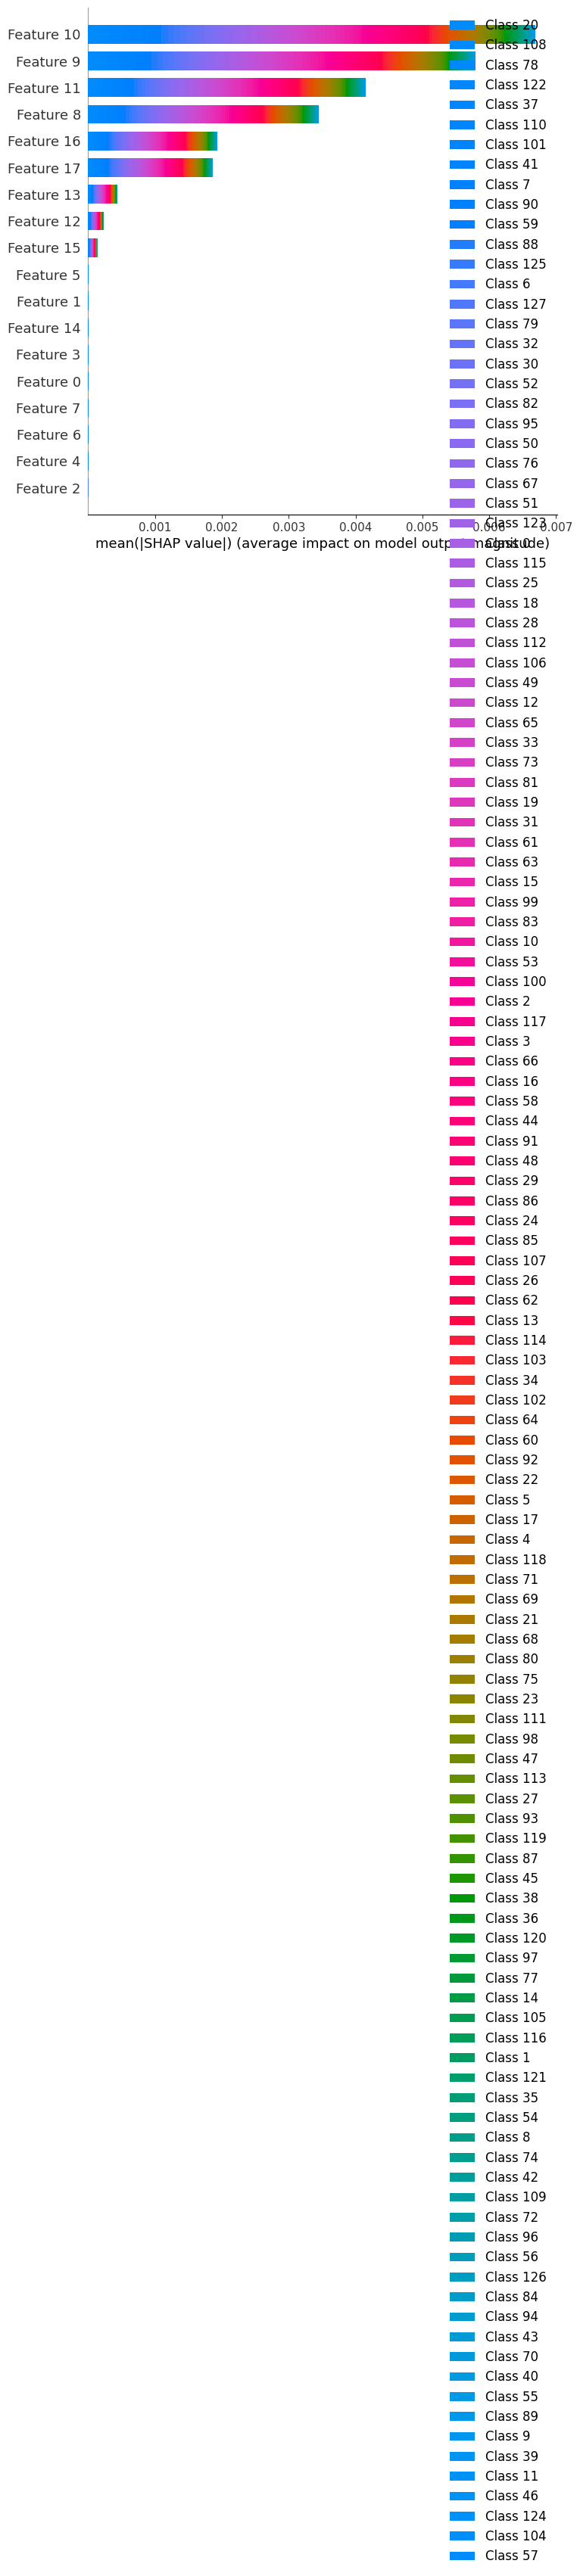

In [11]:
shap.summary_plot(shap_values, dqn_s)